Trie Graphs: 
title: Vertices as Sequences, Tree Decomposition by Definition

Idea: vertices are labelled by sequences. Store edges at least common ancestor / prefix of the two vertices it connects.

This gets a tree decomposition of sorts by definition

Regular trees / asts can be stored at their paths.
I guess we can also allow joining back to share subchildren? This isn't quite the bubble picture


Vertices are lbaelled vy sequences, but we don't need to store the common prefix at the node. In this manner, we can hash cons the tries


Patterns considered as multisequence patterns?

A tree is basically a connection between every vertex and it's immeidate prefix


In [ ]:
from dataclasses import dataclass, field
type Suffix = tuple[int,...] # a suffix of a vertex
type Prefix = tuple[int,...] # a prefix of a vertex

@dataclass
class Graph:
    edges : list[tuple[Suffix, Suffix]] = field(default_factory=list)# everything shares
    sub : dict[Prefix, "Graph"] = field(default_factory=dict) # next prefix to a vertex

((), ())

Graph(edges = [
    ((), (1,)),
    ((), (0,)),
    ],
    sub={
        (0,) : Graph(),
        (1,) : Graph()
    }
    )



Graph(edges=[((), (1,)), ((), (0,))], sub={(0,): Graph(edges=[], sub={}), (1,): Graph(edges=[], sub={})})

In [ ]:
type Vert = tuple[int, ...]
class Graph:
    vert : bool # Is this a vertex node? Or prefix compress
    edges : list[tuple[Vert,Vert]]
    sub : dict[int, Graph]

In [5]:
import networkx as nx
from networkx.algorithms.approximation import treewidth_min_degree

G = nx.cycle_graph(5)
treewidth, T = treewidth_min_degree(G)
print(T.nodes()) # bags
print(T.edges())


[frozenset({2, 3, 4}), frozenset({1, 2, 4}), frozenset({0, 1, 4})]
[(frozenset({2, 3, 4}), frozenset({1, 2, 4})), (frozenset({1, 2, 4}), frozenset({0, 1, 4}))]


Label vertices by position. use tree width.
But I want rooted treewidth? Can I convert from unidrected?

VSA style / multiterm style graphs.

t + t. We don't even hash cons. Is that bad? Why aren't we? Well, we're labelling from the root. In what sense are t_left and t_right the same? A sepcial case for subtrees?
Graph isomorphism. Is graph isomorphism easy given a tree deomp? Given a deterministic tree decomp?

Rather than label nodes by their path, i could label them by their tree? but then what label to use? Context?

A persistent Map data structure can store all graphs with minimal fuss. What is it I'm achieving?
I guess that future rewrites in one area are shared. Yes. That's valid.

NodeView((frozenset({('lam', 'lam', '+', 1), ('lam', 'lam'), ('lam', 'lam', '+')}), frozenset({('lam', 'lam'), ('lam', 'lam', '+'), ('lam', 'lam', '+', 0)}), frozenset({('lam',), ('lam', 'lam'), ('lam', 'lam', '+', 0)})))

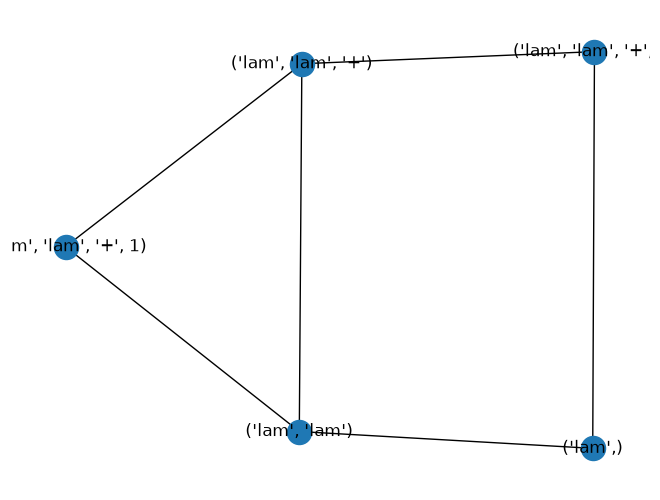

In [24]:
positions = [("lam",), ("lam", "lam"), ("lam", "lam", "+"), ("lam", "lam", "+", 0), ("lam", "lam", "+", 1)] 

G = nx.Graph()
for p in positions:
    for p2 in positions:
        if len(p) + 1 == len(p2) and p2[:len(p)] == p:
            G.add_edge(p, p2)
G.add_edge(("lam", "lam", "+", 0) , ("lam",)) # x
G.add_edge(("lam", "lam", "+", 1) , ("lam", "lam"))
nx.draw(G, with_labels=True)

treewidth, T = treewidth_min_degree(G)
T.nodes